In [1]:
!pip install ultralytics

In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.184 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.3/112.6 GB disk)


In [3]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="FYjpwY1xh2aHXhoUuur4")
project = rf.workspace("university-bswxt").project("crack-bphdr")
version = project.version(2)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [5]:
import os

In [28]:
def get_files(folder_path):
  if os.path.exists(folder_path) and os.path.isdir(folder_path):
    files = [ f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    num_files = len(files)
    print(f"Number of files in {folder_path} : {num_files}")
  else:
    print(f"Folder {folder_path} does not exists")

In [29]:

def check_files(dir_path, structure=['images', 'labels']):
  folders = os.listdir(dir_path) # ['valid', 'train', 'data.yaml', 'README.dataset.txt', 'test', 'README.roboflow.txt']
  for folder in folders:
    folder_path = os.path.join(dir_path, folder) # /content/crack-2/valid, /content/crack-2/train
    if os.path.isdir(folder_path):
      sub_folders = os.listdir(folder_path) # ['images', 'labels']
      for sub_folder in sub_folders:
        if sub_folder in structure:
          final_path = os.path.join(folder_path, sub_folder)  # /content/crack-2/valid/images, /content/crack-2/valid/labels
          get_files(final_path)


In [30]:
check_files('/content/crack-2')

Number of files in /content/crack-2/valid/images : 200
Number of files in /content/crack-2/valid/labels : 200
Number of files in /content/crack-2/train/images : 3717
Number of files in /content/crack-2/train/labels : 3717
Number of files in /content/crack-2/test/images : 112
Number of files in /content/crack-2/test/labels : 112


## Model Training

In [31]:
from ultralytics import YOLO

In [32]:
model = YOLO("yolo11m-seg.pt")

In [36]:
data_path = "/content/crack-2/data.yaml"
epochs = 50
input_image_size=640
patience = 5
batch= 4
val = True
cache = True
cache = "disk"
plots = True
project="yolov11-crack"

In [37]:
results = model.train(
    data=data_path,
    epochs=epochs,
    imgsz=input_image_size,
    patience=patience,
    batch=batch,
    cache=cache,
    plots=plots,
    project=project
)

Ultralytics 8.3.184 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/crack-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective=0.0, plots=True, pose=12.0, pretrained=T

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 775.4±269.1 MB/s, size: 27.4 KB)


train: Scanning /content/crack-2/train/labels.cache... 3717 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3717/3717 [00:00<?, ?it/s]
train: Caching images (1.8GB Disk): 100%|██████████| 3717/3717 [00:00<00:00, 28937.89it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 377.3±188.4 MB/s, size: 34.5 KB)


...

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):   8%|▊         | 2/25 [00:00<00:06,  3.66it/s]

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 25/25 [00:05<00:00,  4.34it/s]


                   all        200        249      0.686      0.691      0.693      0.423      0.618      0.618      0.529      0.167
Speed: 0.3ms preprocess, 15.3ms inference, 0.0ms loss, 3.5ms postprocess per image
Results saved to yolov11-crack/train


In [38]:
# Zip the train file
!zip -r runs.zip /content/yolov11-crack

  adding: content/yolov11-crack/ (stored 0%)
  adding: content/yolov11-crack/train/ (stored 0%)
  adding: content/yolov11-crack/train/weights/ (stored 0%)
  adding: content/yolov11-crack/train/weights/best.pt (deflated 8%)
  adding: content/yolov11-crack/train/weights/last.pt (deflated 8%)
  adding: content/yolov11-crack/train/MaskPR_curve.png (deflated 20%)
  adding: content/yolov11-crack/train/val_batch2_pred.jpg (deflated 9%)
  adding: content/yolov11-crack/train/train_batch2.jpg (deflated 4%)
  adding: content/yolov11-crack/train/confusion_matrix_normalized.png (deflated 36%)
  adding: content/yolov11-crack/train/train_batch0.jpg (deflated 4%)
  adding: content/yolov11-crack/train/BoxF1_curve.png (deflated 16%)
  adding: content/yolov11-crack/train/val_batch1_pred.jpg (deflated 8%)
  adding: content/yolov11-crack/train/MaskF1_curve.png (deflated 17%)
  adding: content/yolov11-crack/train/MaskP_curve.png (deflated 14%)
  adding: content/yolov11-crack/train/results.csv (deflated 58%)

In [39]:
load_model = YOLO("/content/yolov11-crack/train/weights/best.pt")


image 1/1 /content/drive/MyDrive/Machine-Learning/YOLO11/yolo-datasets/stone-crack-01.jpg: 416x640 5 cracks, 37.2ms
Speed: 2.3ms preprocess, 37.2ms inference, 2.6ms postprocess per image at shape (1, 3, 416, 640)


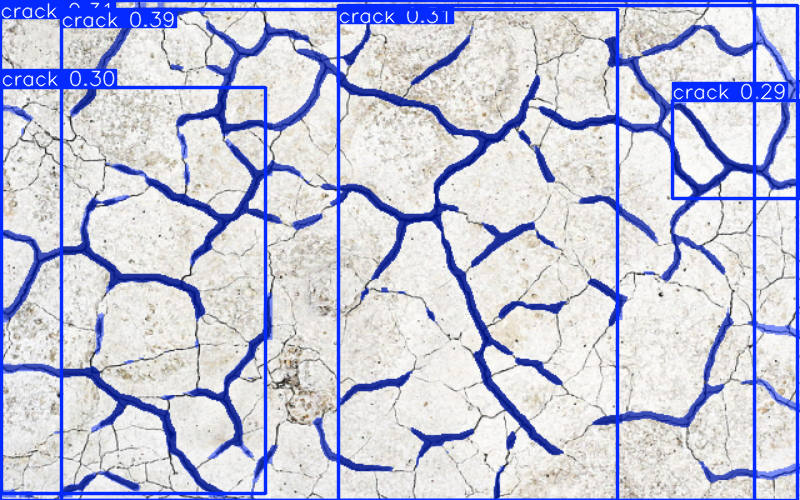

In [41]:
image_path = "/content/drive/MyDrive/Machine-Learning/YOLO11/yolo-datasets/stone-crack-01.jpg"
results = load_model(image_path)

for result in results:
  result.show()
  file_name, ext = os.path.splitext(image_path)
  result.save(filename=f"{file_name}_output.jpg")


## Inferance on Batch of images

In [42]:
img_path_1 = "/content/drive/MyDrive/Machine-Learning/YOLO11/yolo-datasets/stone-crack-01.jpg"
img_path_2 = "/content/drive/MyDrive/Machine-Learning/YOLO11/yolo-datasets/stone-crack-02.jpg"
img_path_3 = "/content/drive/MyDrive/Machine-Learning/YOLO11/yolo-datasets/stone-crack-03.jpg"
img_path_4 = "/content/drive/MyDrive/Machine-Learning/YOLO11/yolo-datasets/stone-crack-04.jpg"

batch = [img_path_1, img_path_2, img_path_3, img_path_4]

results = load_model(batch)

for index, result in enumerate(results):
  # display the image
  result.show()

  file_name, ext = os.path.splitext(batch[index])
  result.save(filename=f"{file_name}_output_{index}.jpg")



Output hidden; open in https://colab.research.google.com to view.

## Inference On np.array

In [43]:
import cv2
import numpy as np

In [46]:
image_path = "/content/drive/MyDrive/Machine-Learning/YOLO11/yolo-datasets/stone-crack-05.jpg"
image_array = cv2.imread(image_path)

results = load_model(image_array)

for result in results:
  result.show()
  result.save(filename="output.jpg")

Output hidden; open in https://colab.research.google.com to view.

## Extract masks

In [47]:
import torch
import matplotlib.pyplot as plt


0: 448x640 2 cracks, 38.1ms
Speed: 4.1ms preprocess, 38.1ms inference, 2.7ms postprocess per image at shape (1, 3, 448, 640)
<class 'list'>
class tensor([0., 0.], device='cuda:0')
Object indices (tensor([0, 1], device='cuda:0'),)


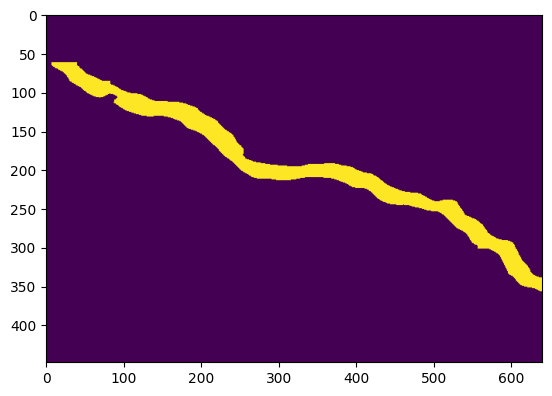

In [51]:
results = load_model(image_array)
print(type(results))

for result in results:
  if result.masks:
    # get array results
    masks = result.masks.data
    boxes = result.boxes.data

    # extract class
    # [x, y, x2, y2, cls]
    clas = boxes[: , 5]
    print("class", clas)

    # get indices of results where class is 0
    object_indices = torch.where(clas == 0)
    print("Object indices", object_indices)

    # Use the indices to extract the relevent mask
    crack_mask = masks[object_indices]

    if len(crack_mask) == 0:
      print("No mask image found")

    # Scale image for visualizating results
    mask = torch.any(crack_mask, dim=0).to(torch.uint8) * 255
    mask = mask.cpu().numpy()
    plt.imshow(mask)
